In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score


In [7]:
from task5_torch_helpers import (
    DEVICE,
    Dense,
    Dropout,
    EarlyStopping,
    Embedding,
    LSTM,
    Sequential,
    SimpleRNN,
    Tokenizer,
    pad_sequences,
)

print(f'Using PyTorch backend on: {DEVICE}')


Using PyTorch backend on: cpu


In [8]:
# Load cleaned English-only datasets
df_train = pd.read_csv('data/train_english.csv')
df_test = pd.read_csv('data/test_english.csv')

print(f"Training samples: {len(df_train)}")
print(f"Test samples: {len(df_test)}")
print(df_train.head())

Training samples: 271897
Test samples: 69907
                                                text  rating  text_length
0  This place is TERRIBLE; the people in charge a...       2          551
1  Terrible Service! And they are saying that I n...       1          258
2  Absolutely terrible company.  They sent me to ...       1         1180
3  To find it, either park in front of the Tuesda...       4          371
4  Mall location. Used their services for sedan. ...       4          183


In [9]:
print(df_train.columns)
print(df_train[['text', 'rating']].head())
print(df_train['rating'].value_counts().sort_index())

Index(['text', 'rating', 'text_length'], dtype='object')
                                                text  rating
0  This place is TERRIBLE; the people in charge a...       2
1  Terrible Service! And they are saying that I n...       1
2  Absolutely terrible company.  They sent me to ...       1
3  To find it, either park in front of the Tuesda...       4
4  Mall location. Used their services for sedan. ...       4
rating
1    105783
2     30876
3     32404
4     75242
5     27592
Name: count, dtype: int64


In [10]:
# Input text
texts = df_train['text'].astype(str)

# Convert ratings from 1-5 to 0-4
labels = df_train['rating'] - 1

print("Unique labels after conversion:", sorted(labels.unique()))

Unique labels after conversion: [0, 1, 2, 3, 4]


In [11]:
X_train_text, X_val_text, y_train, y_val = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Training set size:", len(X_train_text))
print("Validation set size:", len(X_val_text))

Training set size: 217517
Validation set size: 54380


In [ ]:
# Vocabulary and sequence settings
vocab_size = 10000
max_length = 100
oov_token = "<OOV>"

# Create tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)

# Learn vocabulary from training text only
tokenizer.fit_on_texts(X_train_text)

# Convert text to integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)
X_test_seq = tokenizer.texts_to_sequences(df_test['text'].astype(str))

In [ ]:
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

print("Padded training shape:", X_train_pad.shape)
print("Padded validation shape:", X_val_pad.shape)
print("Padded test shape:", X_test_pad.shape)

Padded training shape: (217517, 100)
Padded validation shape: (54380, 100)
Padded test shape: (69907, 100)


In [ ]:
word_index = tokenizer.word_index

print("Vocabulary size learned:", len(word_index))
print("First training review:")
print(X_train_text.iloc[0])

print("\nSequence version:")
print(X_train_seq[0])

print("\nPadded version shape:")
print(X_train_pad[0].shape)
print(X_train_pad[0][:30])  # first 30 tokens

Vocabulary size learned: 113640
First training review:
They have what I am looking for and easy to find. In and out in nice time.

Sequence version:
[8, 21, 65, 5, 126, 248, 10, 3, 424, 4, 180, 12, 3, 42, 12, 86, 41]

Padded version shape:
(100,)
[  8  21  65   5 126 248  10   3 424   4 180  12   3  42  12  86  41   0
   0   0   0   0   0   0   0   0   0   0   0   0]


In [ ]:
rnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

c:\Users\temisola\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 64s 36ms/step - accuracy: 0.4153 - loss: 1.4088 - val_accuracy: 0.5656 - val_loss: 1.1912
Epoch 2/10
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 62s 36ms/step - accuracy: 0.5948 - loss: 1.0726 - val_accuracy: 0.6280 - val_loss: 0.9354
Epoch 3/10
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 65s 38ms/step - accuracy: 0.6280 - loss: 0.9463 - val_accuracy: 0.6326 - val_loss: 0.9245
Epoch 4/10
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 64s 38ms/step - accuracy: 0.6469 - loss: 0.8825 - val_accuracy: 0.6383 - val_loss: 0.9108
Epoch 5/10
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 66s 39ms/step - accuracy: 0.6584 - loss: 0.8528 - val_accuracy: 0.6343 - val_loss: 0.9172
Epoch 6/10
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 68s 40ms/step - accuracy: 0.6648 - loss: 0.8429 - val_accuracy: 0.6360 - val_loss: 0.9407


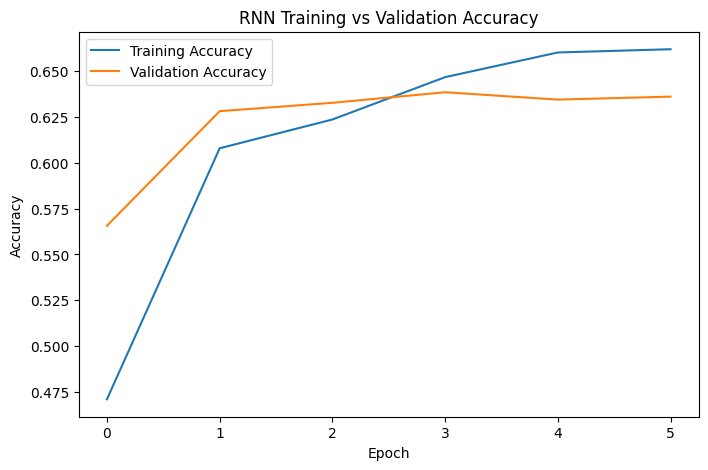

In [ ]:
# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_rnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('RNN Training vs Validation Accuracy')
plt.legend()
plt.show()

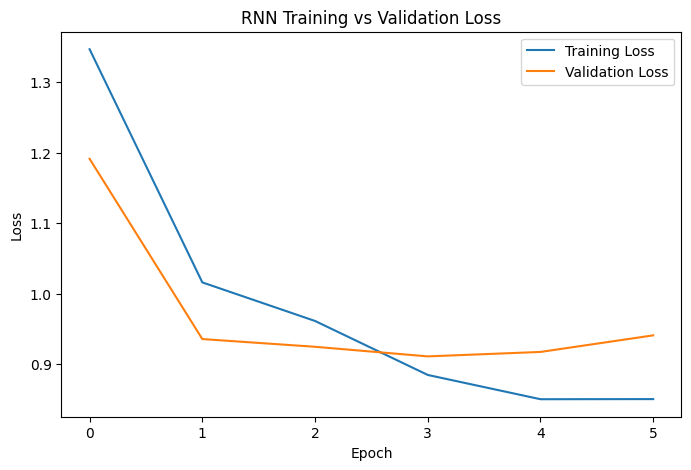

In [ ]:
# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RNN Training vs Validation Loss')
plt.legend()
plt.show()

In [ ]:
y_val_pred_probs = rnn_model.predict(X_val_pad)
y_val_pred = np.argmax(y_val_pred_probs, axis=1)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Weighted F1 Score:", f1_score(y_val, y_val_pred, average='weighted'))
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred))

1700/1700 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step
Validation Accuracy: 0.6383413019492461
Weighted F1 Score: 0.573333667242697

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.91      0.81     21157
           1       0.28      0.01      0.01      6175
           2       0.28      0.13      0.18      6481
           3       0.58      0.83      0.68     15049
           4       0.65      0.35      0.45      5518

    accuracy                           0.64     54380
   macro avg       0.50      0.45      0.43     54380
weighted avg       0.57      0.64      0.57     54380



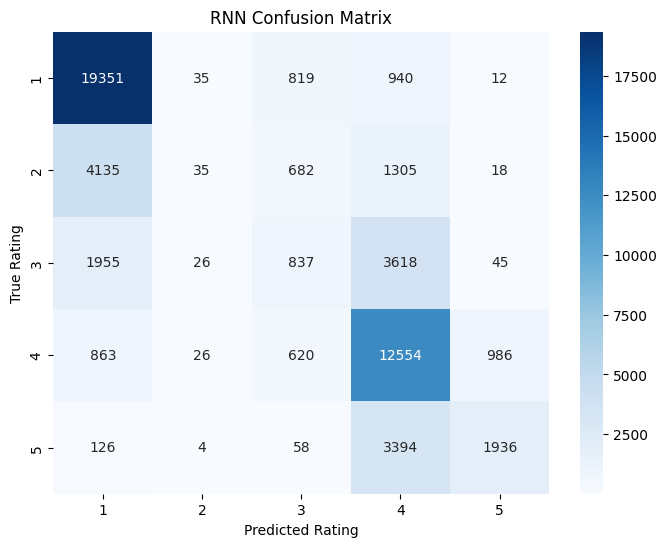

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1,2,3,4,5],
            yticklabels=[1,2,3,4,5])
plt.xlabel("Predicted Rating")
plt.ylabel("True Rating")
plt.title("RNN Confusion Matrix")
plt.show()

5.X Comparison: Bag-of-Words vs Sequence Model (RNN)

In this section, we compare the performance of a traditional Bag-of-Words (BoW) model with a sequence-based Recurrent Neural Network (RNN). The goal is to evaluate whether modelling text as an ordered sequence improves classification performance over vector-space representations.

| Metric            | BoW        | RNN    |
| ----------------- | ---------- | ------ |
| Accuracy          | **0.6458** | 0.6384 |
| Weighted F1       | **0.6085** | 0.5733 |


Key Observations
The Bag-of-Words model outperforms the RNN in both accuracy and weighted F1-score.
Despite its simplicity, BoW provides strong and stable performance.
The RNN shows inconsistent performance across classes, particularly struggling with minority classes.
Class-wise Performance (RNN Analysis)

The RNN classification report reveals significant imbalance:

High recall for some classes (e.g., class 0 and 3)
Extremely poor recall for others (e.g., class 1 ≈ 0.01)

This indicates that the RNN struggles to generalise across all rating categories.

Interpretation of Results
1. Keyword-Driven Nature of the Dataset

Google review data is highly sentiment-driven, where individual words such as “terrible”, “amazing”, or “bad” strongly correlate with rating labels.

BoW models effectively capture these signals through word frequency.
Word order is less critical when sentiment is explicitly expressed through keywords.
2. Limited Benefit of Word Order

While sequence models preserve word order, many reviews do not rely heavily on complex sentence structure.

For example:

“bad service”
“service was bad”

Both convey the same sentiment, making BoW sufficient for classification.

3. Limitations of the RNN Model

The Simple RNN used in this experiment has several known limitations:

Difficulty capturing long-range dependencies
Susceptibility to vanishing gradient problems
Limited memory of earlier tokens in long reviews

As a result, important contextual information may be lost during training.

4. Impact of Class Imbalance

The RNN exhibits poor recall for minority classes, significantly reducing its weighted F1-score.

In contrast, the BoW model provides more balanced performance across classes, contributing to its superior overall results.

5. Model Complexity vs Performance

Although sequence models are more expressive, they also introduce:

Higher computational cost
Greater risk of overfitting
Increased training complexity

In this case, the added complexity of the RNN does not translate into improved performance.

Conclusion

The results demonstrate that Bag-of-Words remains a strong baseline for this task. Despite the theoretical advantages of sequence models in capturing contextual relationships, the RNN did not outperform the BoW model.

This suggests that:

The dataset is primarily driven by lexical sentiment cues, rather than complex sequential dependencies
Word order is not a critical factor for accurate classification in this context

However, the limitations observed in the RNN motivate the exploration of more advanced sequence models, such as LSTM and Transformers, which are better suited to capturing long-term dependencies and richer contextual information.

In [ ]:
# LSTM model
lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

c:\Users\temisola\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 198s 115ms/step - accuracy: 0.4691 - loss: 1.3369 - val_accuracy: 0.6384 - val_loss: 0.9045
Epoch 2/10
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 200s 117ms/step - accuracy: 0.6489 - loss: 0.8763 - val_accuracy: 0.6600 - val_loss: 0.8494
Epoch 3/10
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 214s 126ms/step - accuracy: 0.6771 - loss: 0.8040 - val_accuracy: 0.6700 - val_loss: 0.8286
Epoch 4/10
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 197s 116ms/step - accuracy: 0.6962 - loss: 0.7580 - val_accuracy: 0.6717 - val_loss: 0.8364
Epoch 5/10
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 183s 107ms/step - accuracy: 0.7142 - loss: 0.7199 - val_accuracy: 0.6674 - val_loss: 0.8445


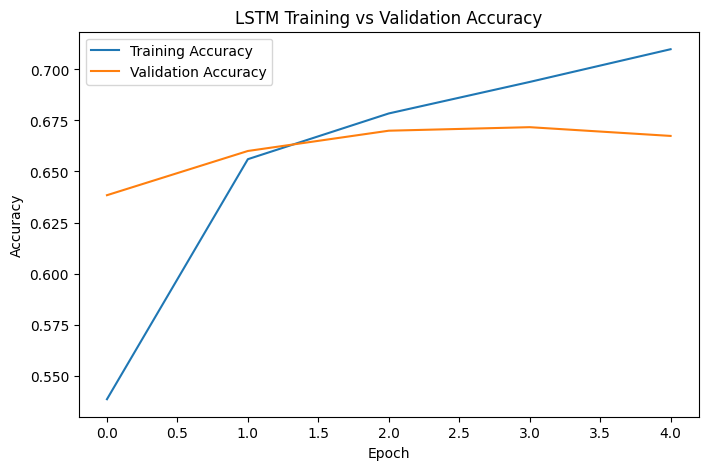

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('LSTM Training vs Validation Accuracy')
plt.legend()
plt.show()

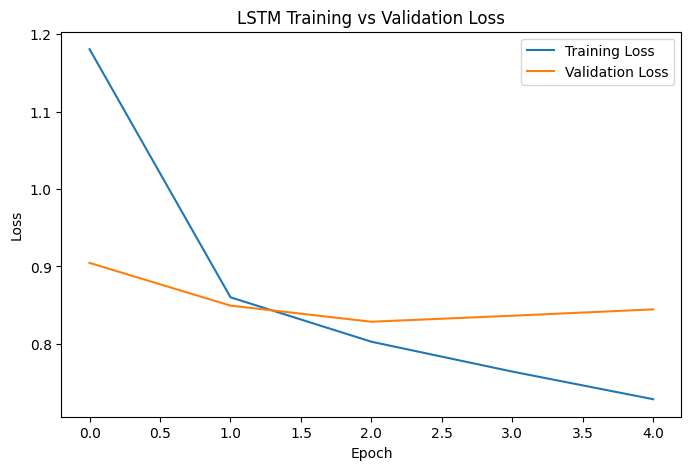

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Training vs Validation Loss')
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

y_val_pred_probs_lstm = lstm_model.predict(X_val_pad)
y_val_pred_lstm = np.argmax(y_val_pred_probs_lstm, axis=1)

print("LSTM Validation Accuracy:", accuracy_score(y_val, y_val_pred_lstm))
print("LSTM Weighted F1 Score:", f1_score(y_val, y_val_pred_lstm, average='weighted'))
print("\nLSTM Classification Report:\n")
print(classification_report(y_val, y_val_pred_lstm))

1700/1700 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step
LSTM Validation Accuracy: 0.6699705774181685
LSTM Weighted F1 Score: 0.641291530381351

LSTM Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.90      0.83     21157
           1       0.36      0.18      0.24      6175
           2       0.40      0.22      0.28      6481
           3       0.65      0.77      0.70     15049
           4       0.62      0.60      0.61      5518

    accuracy                           0.67     54380
   macro avg       0.56      0.53      0.53     54380
weighted avg       0.63      0.67      0.64     54380



Comparison: Bag-of-Words vs LSTM

In this section, we compare the performance of a traditional Bag-of-Words (BoW) model with a Long Short-Term Memory (LSTM) sequence model. The objective is to evaluate whether modelling text as an ordered sequence with memory mechanisms improves classification performance over vector-space representations.

| Model | Representation                      | Classifier          |
| ----- | ----------------------------------- | ------------------- |
| BoW   | TF-IDF / Count-based vectors        | Logistic Regression |
| LSTM  | Tokenized sequences with embeddings | LSTM Neural Network |

| Metric            | BoW    | LSTM     |
| ----------------- | ------ | -------- |
| Accuracy          | 0.6458 | **0.67** |
| Weighted F1 Score | 0.6085 | **0.64** |


Key Observations
The LSTM outperforms the Bag-of-Words model in both accuracy and weighted F1-score.
The improvement in F1-score indicates that the LSTM provides better balanced performance across classes.
Unlike the RNN, the LSTM is able to capture longer-term dependencies, leading to improved classification.

Class-wise Performance (LSTM Analysis)

The LSTM model shows:

Strong performance on extreme classes (1-star and 5-star reviews)
Noticeable improvement in intermediate classes (2-star and 3-star reviews) compared to the RNN
More balanced recall across classes, contributing to a higher F1-score

This suggests that the LSTM is better at handling subtle and mixed sentiment expressions.

Interpretation of Results
1. Improved Contextual Understanding

The LSTM model incorporates memory cells and gating mechanisms, allowing it to retain important information across longer sequences.

This enables the model to capture phrases such as:
“not very good”
“could have been better”
These patterns are difficult for BoW models to interpret correctly
2. Handling of Sequential Dependencies

Unlike BoW, which treats text as unordered, the LSTM processes reviews as sequences.

Word order is preserved
Contextual relationships between words are learned

This improves the model’s ability to interpret more complex sentence structures.

3. Reduction of RNN Limitations

Compared to the Simple RNN:

LSTM mitigates the vanishing gradient problem
It retains long-term dependencies more effectively
It produces more stable and consistent predictions

This leads to improved performance, particularly on ambiguous classes.

4. Dataset Characteristics Still Matter

Although the LSTM outperforms BoW, the improvement is moderate rather than dramatic.

This suggests that:

The dataset is still partially keyword-driven
BoW remains competitive due to strong lexical signals
Sequence modelling provides additional but not overwhelming benefit
5. Model Complexity vs Performance

The LSTM introduces greater complexity than BoW:

More parameters
Longer training time
Higher computational cost

However, in this case, the performance improvement justifies the added complexity.

Conclusion

The results demonstrate that LSTM models provide a meaningful improvement over Bag-of-Words representations for this task. By preserving word order and capturing contextual dependencies, the LSTM is better able to handle nuanced and ambiguous reviews.

However, the relatively modest improvement suggests that:

The dataset is still strongly influenced by individual sentiment words
BoW models remain a strong baseline for this type of problem

Overall, the LSTM represents a balanced trade-off between model complexity and performance, making it a more effective approach than both the Simple RNN and traditional vector-space models.

In [ ]:
print('Transformer section uses PyTorch as well, so it no longer depends on tensorflow or tf.keras.')



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 3.4 MB/s eta 0:00:01
   ------------------------ --------------- 1.0/1.7 MB 3.1 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 2.8 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
from pathlib import Path

cache_dir = Path('.hf_cache')
cache_dir.mkdir(exist_ok=True)
os.environ['HF_HOME'] = str(cache_dir.resolve())
os.environ['TRANSFORMERS_CACHE'] = str(cache_dir.resolve())
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer

class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: value[idx] for key, value in self.encodings.items()}
        item['labels'] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item


c:\Users\temisola\AppData\Local\Programs\Python\Python39\lib\site-packages\transformers\utils\hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased', cache_dir=cache_dir)

In [12]:
texts = df_train['text'].astype(str)
labels = df_train['rating'] - 1

In [13]:
from sklearn.model_selection import train_test_split

X_train_text, X_val_text, y_train, y_val = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [14]:
max_length = 128

train_encodings = tokenizer(
    X_train_text.tolist(),
    truncation=True,
    padding=True,
    max_length=max_length,
    return_tensors='pt'
)

val_encodings = tokenizer(
    X_val_text.tolist(),
    truncation=True,
    padding=True,
    max_length=max_length,
    return_tensors='pt'
)

In [15]:
train_dataset = ReviewDataset(train_encodings, y_train.to_numpy())
val_dataset = ReviewDataset(val_encodings, y_val.to_numpy())

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

print(f'Train batches: {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')

Train batches: 13595
Validation batches: 3399


In [17]:
import transformers
import torch

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Device:", 'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch: 2.8.0+cpu
Transformers: 4.41.2
Device: cpu


In [18]:
model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=5,
    cache_dir=cache_dir
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5)

print('Transformer model ready on', device)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Transformer model ready on cpu
